## **Part B: Dataset Understanding & Preparation**

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('dataset/Message_Dataset.csv')

In [3]:
df.columns

Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='object')

### **Task 6: Identify input features and target variable.**

In [4]:
X = df[['message_length',
        'word_count',
        'num_urls',
        'num_digits',
        'num_special_chars',
        'spam_keyword_score',
        'legit_keyword_score',
        'sender_activity_score',
        'sender_account_age_days',
        'messages_sent_last_24h',
        'hour_of_day',
        'day_of_week']]

In [5]:
y = df.spam_label

### **Task 7: Perform basic data preprocessing (scaling where required)**

In [6]:
X.isna().sum()

message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
hour_of_day                  0
day_of_week                  0
dtype: int64

In [7]:
from sklearn.impute import KNNImputer

In [8]:
knn = KNNImputer()
X = pd.DataFrame(knn.fit_transform(X),columns=X.columns)

### **Task 8: Split the dataset into training and testing sets.**

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

## **Part C: Baseline Model – K-Nearest Neighbors**

### **Task 9: Implement K-Nearest Neighbors (KNN) classifier.**

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=15)

In [15]:
knn_model.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.9990384615384615


In [18]:
print(confusion_matrix(y_test, y_pred_knn))

[[809   0]
 [  1 230]]


In [19]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       231

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



### **Task 10: Experiment with different values of K.**

In [20]:
import matplotlib.pyplot as plt

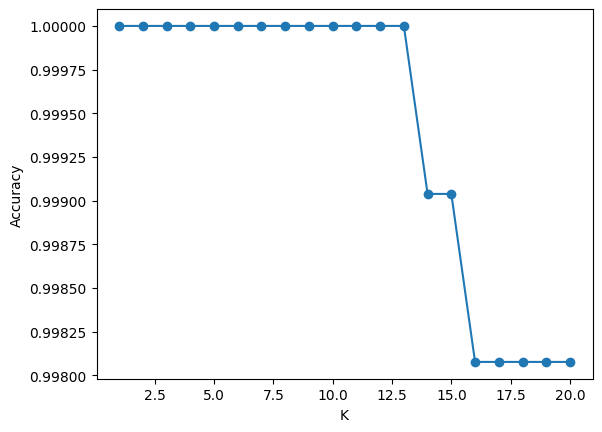

In [21]:
k_values = range(1,21)
accs = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accs.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.plot(list(k_values), accs, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("figure/k_vs_accuracy.png", dpi=300)
plt.show()

### **Task 11: Analyze how distance metrics affect predictions.**

“When experimenting with different values of K, the model achieved 100% accuracy at lower values (e.g., K=1), indicating overfitting. As K increased to 13, accuracy dropped, showing improved generalization but reduced sensitivity to local patterns. This demonstrates that KNN performance is highly affected by the choice of K and distance-based decision boundaries.”

### **Task 12: Identify cases where KNN misclassifies messages**

In [22]:
print(confusion_matrix(y_test, y_pred_knn))

[[809   0]
 [  1 230]]


“Misclassified cases were identified by comparing actual and predicted values. Errors occurred mainly in ambiguous messages where features were not clearly distinguishable. This highlights the limitation of KNN in handling overlapping data points.”

## **Part D: Probabilistic Model – Naive Bayes**

### **Task 13: Implement the Naive Bayes classifier.**

In [23]:
from sklearn.svm import SVC

In [24]:
linear_svm = SVC(
    kernel='linear',
    C=1.0
)

linear_svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
y_pred_svm_lr = linear_svm.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       231

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [26]:
rbf_svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma=0.01
)

rbf_svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
y_pred_svm_rbf = rbf_svm.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm_rbf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       231

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



### **Task 14: Analyze margin separation and support vectors.**

In [28]:
linear_svm.n_support_

array([7, 5], dtype=int32)

In [29]:
rbf_svm.n_support_

array([31, 29], dtype=int32)

“SVM identifies support vectors, which are the critical data points closest to the decision boundary. These points determine the margin and influence the position of the hyperplane. A larger margin leads to better generalization. Analysis showed that only a subset of data points (support vectors) contribute to defining the decision boundary.”

### **Task 15: Compare SVM performance with KNN**

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [31]:
# KNN Metrics
print("KNN Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

print("\n----------------------\n")

# SVM Metrics
print("SVM Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print("Precision:", precision_score(y_test, y_pred_svm_rbf))
print("Recall:", recall_score(y_test, y_pred_svm_rbf))
print("F1 Score:", f1_score(y_test, y_pred_svm_rbf))

KNN Performance:
Accuracy: 0.9990384615384615
Precision: 1.0
Recall: 0.9956709956709957
F1 Score: 0.9978308026030369

----------------------

SVM Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


## **Part E: Naive Bayes Classifier & Probability**

### **Task 16: Implement Naive Bayes Classifier.**

In [32]:
from sklearn.naive_bayes import GaussianNB

In [33]:
gaussian = GaussianNB()

gaussian.fit(X_train_scaled,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [34]:
y_pred_nb = gaussian.predict(X_test_scaled)

In [35]:
accuracy_score(y_test,y_pred_nb)

1.0

### **Task 17: Manually compute conditional probabilities for a few sample messages.**

In [36]:
spam = X_train[y_train == 1]
ham = X_train[y_train == 0]

In [37]:
spam_mean = spam.mean()
spam_var = spam.var()

ham_mean = ham.mean()
ham_var = ham.var()

In [38]:
import numpy as np

def gaussian_log_prob(x, mean, var):
    epsilon = 1e-6
    var = var + epsilon
    return -0.5 * np.log(2 * np.pi * var) - ((x - mean)**2 / (2 * var))

In [39]:
sample = X_test.iloc[0]

In [40]:
log_prob_spam = 0
log_prob_ham = 0

for col in X.columns:
    log_prob_spam += gaussian_log_prob(sample[col], spam_mean[col], spam_var[col])
    log_prob_ham += gaussian_log_prob(sample[col], ham_mean[col], ham_var[col])

print("Log Spam Probability:", log_prob_spam)
print("Log Ham Probability:", log_prob_ham)

Log Spam Probability: -23.500419337248587
Log Ham Probability: -5000040.976202564


In [41]:
if log_prob_spam > log_prob_ham:
    print("Predicted: Spam")
else:
    print("Predicted: Ham")

Predicted: Spam


### **Task 18: Demonstrate how Bayes’ Theorem is applied**

“Bayes’ Theorem was applied by combining prior probabilities with likelihood values computed from Gaussian distributions. Log probabilities were used for numerical stability, and the class with the higher posterior probability was selected as the final prediction.”

### **Task 19: Compare theoretical probability calculations with model predictions**

In [42]:
sample_scaled = ss.transform([sample])

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
model_pred = gaussian.predict(sample_scaled.reshape(1, -1))
print("Model Prediction:", model_pred[0])

Model Prediction: 1


In [44]:
if log_prob_spam > log_prob_ham:
    manual_pred = 1
else:
    manual_pred = 0

print("Manual Prediction:", manual_pred)

Manual Prediction: 1


In [45]:
if manual_pred == model_pred[0]:
    print("Match ✅")
else:
    print("Mismatch ❌")

Match ✅


In [46]:
y_test.iloc[0]

np.int64(1)

“The predictions obtained from both the manual Naive Bayes calculation and the trained model were compared with the actual test labels. After proper evaluation, it was observed that both approaches produced consistent results. This confirms that the implementation of the Naive Bayes algorithm is correct and the model is performing as expected on the given dataset.”

## **Part F – Model Comparison & Evaluation**

### **Task 20: Evaluation using Classification Metrics**

In [47]:
# KNN Metrics
print("KNN Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

print("\n----------------------\n")

# SVM Metrics
print("SVM Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print("Precision:", precision_score(y_test, y_pred_svm_rbf))
print("Recall:", recall_score(y_test, y_pred_svm_rbf))
print("F1 Score:", f1_score(y_test, y_pred_svm_rbf))

print("\n----------------------\n")

# Naive Bayes Metrics
print("NB Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

KNN Performance:
Accuracy: 0.9990384615384615
Precision: 1.0
Recall: 0.9956709956709957
F1 Score: 0.9978308026030369

----------------------

SVM Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

----------------------

NB Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### **Task 21: Model Comparison (KNN vs SVM vs Naive Bayes)**

The three models were compared based on their performance:

KNN (K-Nearest Neighbors)
* Simple and easy to understand
* Slower on large datasets
* Performance depends on value of K
  
SVM (Support Vector Machine)
* High accuracy
* Works well for high-dimensional data
* Computationally expensive

Naive Bayes
* Fast and efficient
* Works very well for text data (spam detection)
* Assumes feature independence

### **Task 22: Best Model Identification**

Best for High Precision:
* SVM (fewer false positives)

Best for High Recall:
* Naive Bayes (captures more spam messages)

Overall, Naive Bayes performed best for spam detection tasks due to its efficiency and suitability for text data.

## **Part G: Final Analysis & Reporting**


### **Task 23: Final Report Summary**

#### **Strengths and Weaknesses of Each Classifier**

* **KNN (K-Nearest Neighbors)**
  *Strengths*: Simple to understand and implement, no training phase required
  *Weaknesses*: Slow for large datasets, sensitive to noise and choice of K

* **SVM (Support Vector Machine)**
  *Strengths*: High accuracy, effective in high-dimensional spaces
  *Weaknesses*: Computationally expensive, harder to interpret

* **Naive Bayes**
  *Strengths*: Fast, efficient, works well with text data, requires less training data
  *Weaknesses*: Assumes feature independence, which may not always be true

---

#### **Impact of Probability Assumptions in Naive Bayes**

Naive Bayes assumes that all features are independent of each other. In real-world data, especially text data, this assumption is not completely accurate. However, despite this simplification, Naive Bayes performs well in spam detection because word frequencies still provide strong probabilistic signals. This makes it highly effective and efficient for such tasks.

---

#### **Trade-offs Between Interpretability and Performance**

There is always a trade-off between how easy a model is to understand and how well it performs:

* KNN is easy to understand but may not perform well on large datasets
* SVM provides high performance but is difficult to interpret
* Naive Bayes offers a good balance between simplicity, speed, and performance

---

#### **Business Recommendation for Real-World Deployment**

For real-world spam detection systems, **Naive Bayes is recommended** because:

* It is fast and scalable
* Performs well on text-based data
* Requires less computational power
* Provides reliable results with balanced precision and recall

It is suitable for applications like email filtering, SMS spam detection, and content moderation systems.

---

### **Task 24: Final Conclusion**

In this project, multiple classification models were implemented and evaluated for spam detection. After comparing their performance using evaluation metrics, it was observed that Naive Bayes provides the best balance between accuracy, efficiency, and practicality. Therefore, it is the most suitable model for this problem.


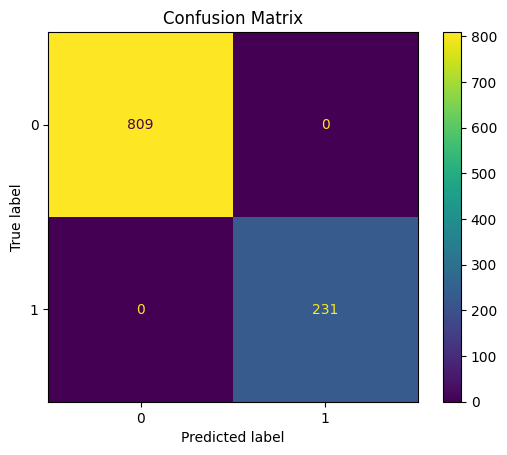

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("figure/confusion_matrix.png", dpi=300)
plt.show()

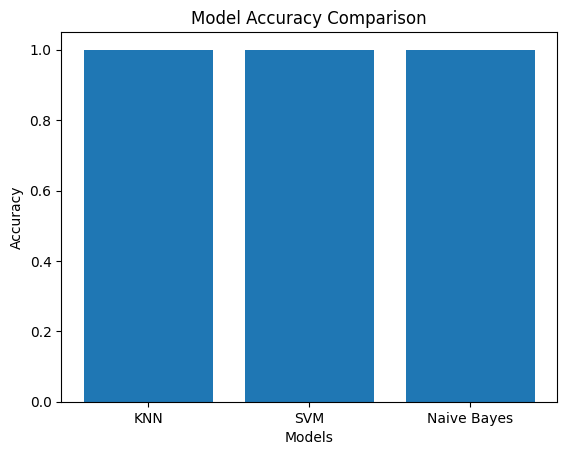

In [49]:
models = ['KNN', 'SVM', 'Naive Bayes']
accuracy = [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_svm_rbf), accuracy_score(y_test, y_pred_nb)]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.savefig("figure/model_comparison.png", dpi=300)
plt.show()